<a href="https://colab.research.google.com/github/shivanjali26/NLP/blob/main/NLP_Assignment12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
files.upload()  # Upload kaggle.json

Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"shivanjalibhosale26","key":"0578876fe5e45c2ea5a9b5ff9dedd592"}'}

In [18]:
import os

os.makedirs('/root/.kaggle (1)', exist_ok=True)
os.rename('kaggle (1).json', '/root/.kaggle/kaggle (1).json')
os.chmod('/root/.kaggle/kaggle (1).json', 600)

In [5]:
!pip install kaggle

!kaggle datasets download -d kienngx/nemotron-30b-competition-trainingdata-cot-labels
!unzip nemotron-30b-competition-trainingdata-cot-labels.zip

Dataset URL: https://www.kaggle.com/datasets/kienngx/nemotron-30b-competition-trainingdata-cot-labels
License(s): apache-2.0
100% 3.72M/3.72M [00:00<00:00, 214MB/s]

Archive:  nemotron-30b-competition-trainingdata-cot-labels.zip
  inflating: final_Nemotron_training_data.csv  


In [19]:
import pandas as pd

df = pd.read_csv("final_Nemotron_training_data.csv")

print(df.head())
print(df.columns)

         id                                             prompt  \
0  00066667  In Alice's Wonderland, a secret bit manipulati...   
1  000b53cf  In Alice's Wonderland, a secret bit manipulati...   
2  00189f6a  In Alice's Wonderland, secret encryption rules...   
3  001b24c4  In Alice's Wonderland, numbers are secretly co...   
4  001c63cb  In Alice's Wonderland, secret encryption rules...   

                  answer                                      generated_cot  \
0               10010111  The transformation seems complex and non-linea...   
1               01000011  The task is to deduce a bit manipulation rule ...   
2      cat imagines book  The task is to decrypt the text "trb wzrswvog ...   
3                XXXVIII  The task is to convert 38 to Roman numerals ba...   
4  wizard creates secret  The task is to decrypt "hncreo learpaq qaleap"...   

                                            label  
0         bitwise and binary transformation tasks  
1         bitwise and bi

In [20]:
print(df.columns)

Index(['id', 'prompt', 'answer', 'generated_cot', 'label'], dtype='object')


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df.fillna("")

df["text"] = df["prompt"] + " " + df["generated_cot"] + " " + df["answer"]

le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train_vec, y_train)

print("Logistic Regression Accuracy:", lr.score(X_test_vec, y_test))

Logistic Regression Accuracy: 0.9278947368421052


In [11]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_vec, y_train)

print("SVM Accuracy:", svm.score(X_test_vec, y_test))

SVM Accuracy: 0.9152631578947369


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_vec, y_train)

print("Random Forest Accuracy:", rf.score(X_test_vec, y_test))

Random Forest Accuracy: 0.9336842105263158


In [13]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

print("Naive Bayes Accuracy:", nb.score(X_test_vec, y_test))

Naive Bayes Accuracy: 0.9010526315789473


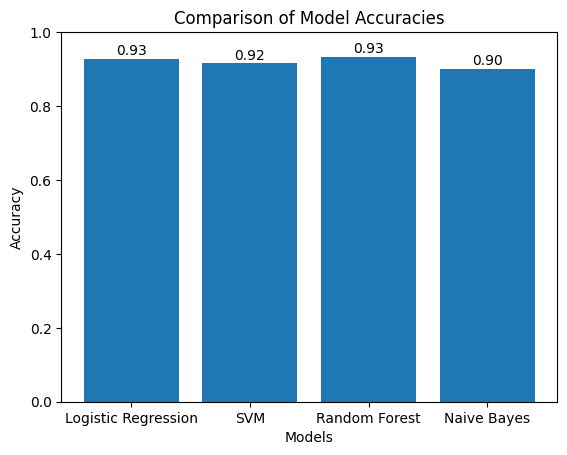

In [14]:
import matplotlib.pyplot as plt

lr_acc = lr.score(X_test_vec, y_test)
svm_acc = svm.score(X_test_vec, y_test)
rf_acc = rf.score(X_test_vec, y_test)
nb_acc = nb.score(X_test_vec, y_test)

models = ['Logistic Regression', 'SVM', 'Random Forest', 'Naive Bayes']
accuracies = [lr_acc, svm_acc, rf_acc, nb_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()